In [1]:
import pandas as pd

from google.colab import files
uploaded = files.upload()
# load the dataset
df = pd.read_csv("students.csv")
print("First 5 rows:")
print(df.head())
print()

Saving students.csv to students.csv
First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  



In [ ]:
# step 2 - shape and data types
# ─────────────────────────────────────────

print("Shape (rows x columns):", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()

Shape (rows x columns): (15, 9)

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object



In [ ]:
# step 3 - summary statistics
# ─────────────────────────────────────────

print("Summary statistics:")
print(df.describe())
print()

Summary statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2

In [ ]:
# step 4 - count passed and failed
# ─────────────────────────────────────────

print("Pass/Fail count:")
print(df["passed"].value_counts())
print()


Pass/Fail count:
passed
1    9
0    6
Name: count, dtype: int64



In [ ]:
#step 5
subject_cols = ["math", "science", "english", "history", "pe"]

# passing students average
passing_avg = df[df["passed"] == 1][subject_cols].mean()
print("Average scores for passing students:")
print(passing_avg)
print()

# failing students average
failing_avg = df[df["passed"] == 0][subject_cols].mean()
print("Average scores for failing students:")
print(failing_avg)
print()

Average scores for passing students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average scores for failing students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64



In [ ]:
#step 6
#highest overall average

print(df.loc[df[["math","science","english","history","pe"]].mean(axis=1).idxmax()])

name                   Diana
math                      95
science                   98
english                   91
history                   89
pe                        97
attendance_pct            98
study_hours_per_day      6.0
passed                     1
Name: 3, dtype: object


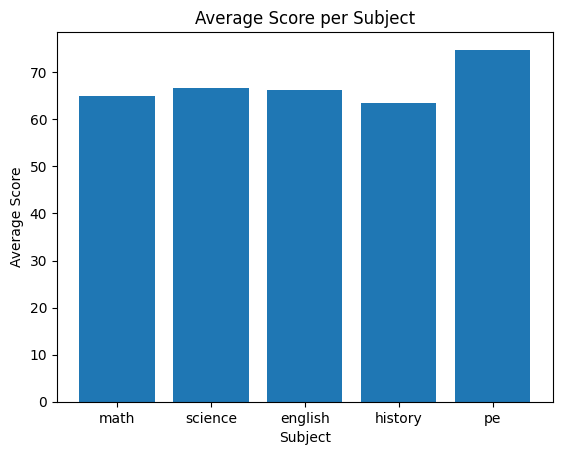

In [ ]:
#TASK 2

import matplotlib.pyplot as plt

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

#step 1: Bar chart
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

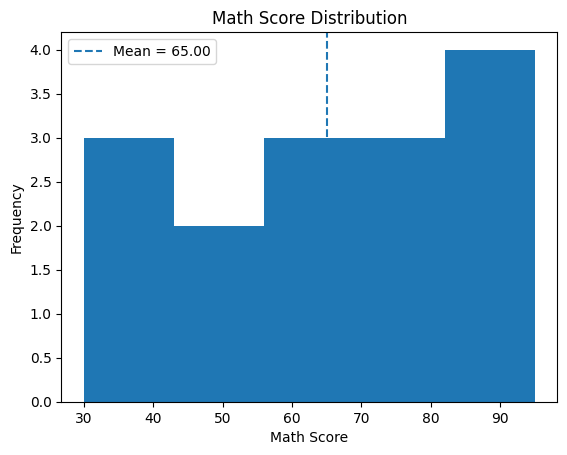

In [ ]:
plt.figure()
plt.hist(df["math"], bins=5)
mean_val = df["math"].mean()

plt.axvline(mean_val, linestyle='dashed', label=f"Mean = {mean_val:.2f}")
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

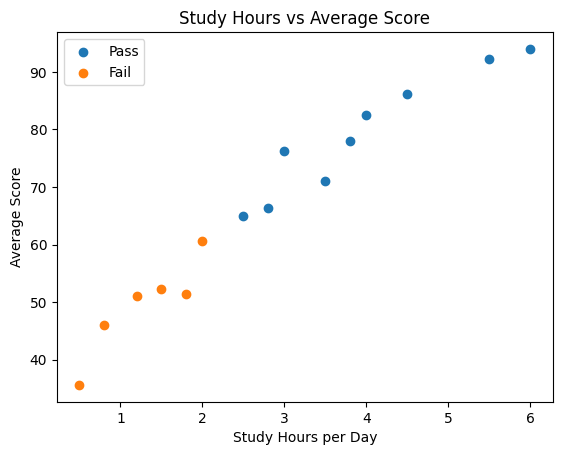

In [ ]:
# step 3: Scatter Plot

plt.figure()

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_23043/1963266195.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])


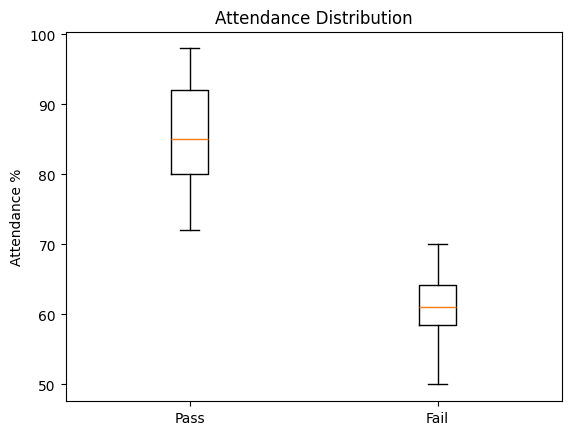

In [ ]:
#step 4: Box Plot
pass_att = df[df['passed']==1]['attendance_pct']
fail_att = df[df['passed']==0]['attendance_pct']

plt.figure()
plt.boxplot([pass_att, fail_att], labels=["Pass", "Fail"])
plt.title("Attendance Distribution")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()

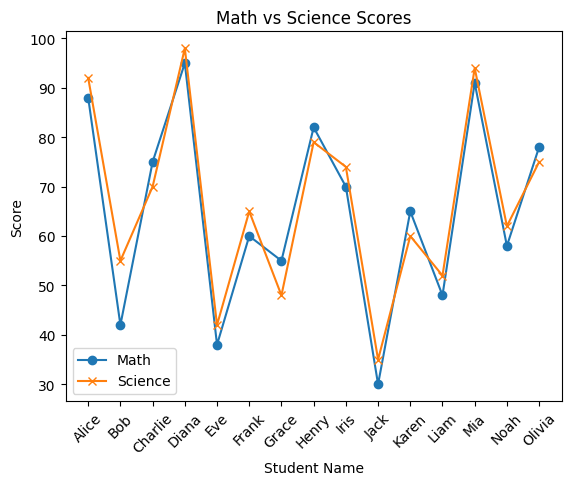

In [ ]:
# Line Plot
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='x', label="Science")

plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

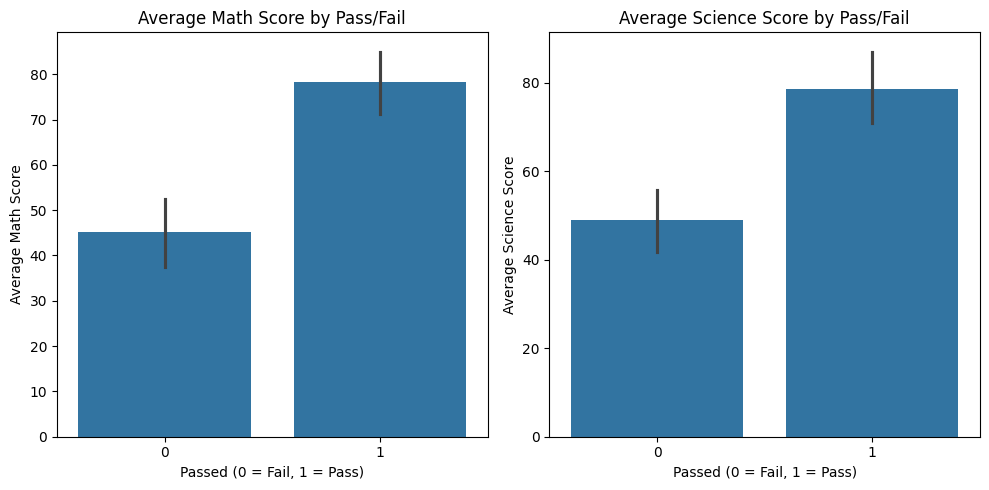

In [ ]:
import seaborn as sns

# ─────────────────────────────────────────
# Plot 1 — Seaborn Bar Plot
# avg math and science score split by passed
# ─────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# math score bar plot
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Average Math Score")

# science score bar plot
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Average Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

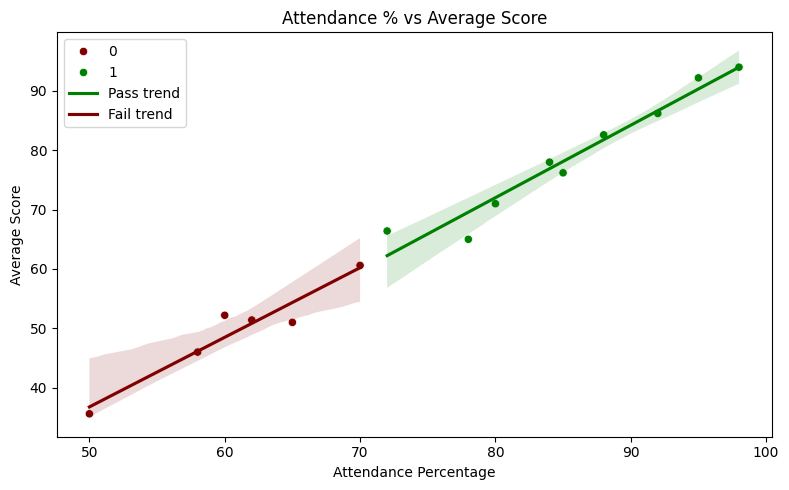

In [ ]:
# attendance vs avg score coloured by passed

plt.figure(figsize=(8, 5))

# scatter plot coloured by passed
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed', palette={1: 'green', 0: 'maroon'})

# regression line for passing students
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            scatter=False, color='green', label='Pass trend')

# regression line for failing students
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            scatter=False, color='maroon', label='Fail trend')

plt.title("Attendance % vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()


In [ ]:
#comparitive study

# Seaborn was easier to use overall. For the bar chart, I just passed x='passed'
# And it automatically grouped the data into pass and fail without me having to filter the dataframe manually.
# In Matplotlib I had to split the data into two groups myself and make two separate plot calls which took more lines of code.
# In Matplotlib I would have had to calculate the line manually which would have been a lot more work.
# Overall I think Seaborn is better for quick data analysis plots.

In [ ]:
# Task 4
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("students.csv")

# Features (exclude 'name' and 'passed')
X = df[["math","science","english","history","pe","attendance_pct","study_hours_per_day"]]

# Target
y = df["passed"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
#Train a model
# using logistic regression to predict pass or fail
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Model trained successfully")
print()

Model trained successfully



In [ ]:
# Predict on test set
y_pred = model.predict(X_test_scaled)

# Test accuracy
test_accuracy = model.score(X_test_scaled, y_test)
print("Test Accuracy:", test_accuracy)

# Get corresponding names
names = df.loc[X_test.index, "name"]

print("\nPredictions:")
for name, actual, pred in zip(names, y_test, y_pred):
    if actual == pred:
        status = "correct"
    else:
        status = "wrong"

    print(f"{name}: Actual={actual}, Predicted={pred} → {status}")

Test Accuracy: 1.0

Predictions:
Jack: Actual=0, Predicted=0 → correct
Liam: Actual=0, Predicted=0 → correct
Alice: Actual=1, Predicted=1 → correct


Feature Importance:
english : 0.8125
attendance_pct : 0.5219
study_hours_per_day : 0.4844
pe : 0.475
math : 0.4379
science : 0.323
history : 0.2629



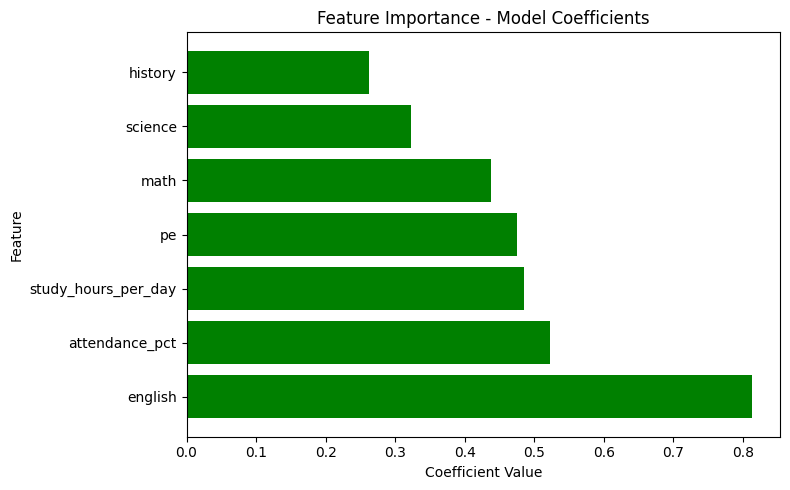

In [ ]:
# step 4 - feature importance

# get model coefficients
coefficients = model.coef_[0]

# feature names
features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

# pair each feature with its coefficient
paired = []
for i in range(len(features)):
    paired.append((features[i], coefficients[i]))

# sort by absolute value, largest first
for i in range(len(paired)):
    for j in range(i + 1, len(paired)):
        if abs(paired[j][1]) > abs(paired[i][1]):
            paired[i], paired[j] = paired[j], paired[i]

# print each feature with its coefficient
print("Feature Importance:")
for item in paired:
    print(item[0] + " : " + str(round(item[1], 4)))

print()


# horizontal bar chart


# separate names and values for plotting
names  = []
values = []
colors = []

for item in paired:
    names.append(item[0])
    values.append(item[1])

    # green for positive, red for negative
    if item[1] >= 0:
        colors.append("green")
    else:
        colors.append("red")

plt.figure(figsize=(8, 5))
plt.barh(names, values, color=colors)
plt.title("Feature Importance - Model Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()

In [ ]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

result = model.predict(new_scaled)
proba  = model.predict_proba(new_scaled)

if result[0] == 1:
    print("Pass")
else:
    print("Fail")

print("Pass chance:", round(proba[0][1] * 100, 2), "%")
print("Fail chance:", round(proba[0][0] * 100, 2), "%")

Pass
Pass chance: 90.8 %
Fail chance: 9.2 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
